In [407]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge , ElasticNet , LinearRegression , Lasso
from sklearn.pipeline import Pipeline
from scipy.special import inv_boxcox1p
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from scipy.stats import boxcox , normaltest , skew ,yeojohnson
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [408]:
df = pd.read_csv(filepath_or_buffer='ev_qiymetleri.csv')

In [409]:
df

,ELAN_ID,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,997387,Ganja,3,88.0,11,0.0,3.0,2369.0,106155
1,260548,Sumqayit,4,174.0,9,0.0,1.0,172.0,157632
2,756065,Baki,4,142.0,4,5.0,0.0,66.0,243584
3,763717,Baki,4,91.0,5,1.0,1.0,101.0,233115
4,525741,Ganja,3,84.0,20,1.0,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...,...
200045,128820,Baki,2,78.0,18,20.0,0.0,1913.0,123474
200046,331674,Ganja,3,119.0,14,17.0,3.0,756.0,115457
200047,195437,Baki,4,82.0,9,10.0,3.0,479.0,260676
200048,759883,Mingachevir,1,52.0,12,18.0,1.0,159.0,43198


In [410]:
df.head()

,ELAN_ID,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,997387,Ganja,3,88.0,11,0.0,3.0,2369.0,106155
1,260548,Sumqayit,4,174.0,9,0.0,1.0,172.0,157632
2,756065,Baki,4,142.0,4,5.0,0.0,66.0,243584
3,763717,Baki,4,91.0,5,1.0,1.0,101.0,233115
4,525741,Ganja,3,84.0,20,1.0,2.0,1599.0,98474


In [411]:
df.tail()

,ELAN_ID,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
200045,128820,Baki,2,78.0,18,20.0,0.0,1913.0,123474
200046,331674,Ganja,3,119.0,14,17.0,3.0,756.0,115457
200047,195437,Baki,4,82.0,9,10.0,3.0,479.0,260676
200048,759883,Mingachevir,1,52.0,12,18.0,1.0,159.0,43198
200049,401589,Baki,4,104.0,13,1.0,2.0,2105.0,264402


In [412]:
df.shape

(200050, 9)

# 0 = Təmirsiz      (ən pis)
# 1 = Orta təmir
# 2 = Yaxşı təmir
# 3 = Əla təmir      (ən yaxşı) təmir sütunu

In [413]:
df.describe()

,ELAN_ID,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
count,200050.000000,200050.000000,199750.000000,200050.000000,199650.000000,199850.000000,199800.000000,200050.000000
mean,551257.733982,2.947858,97.002899,11.004269,10.370443,1.897513,848.675931,164509.397961
std,259899.370078,1.117707,35.124011,6.056334,10.461839,0.899875,843.254415,83502.460831
min,100000.000000,1.000000,22.000000,1.000000,0.000000,0.000000,30.000000,13356.000000
25%,326128.250000,2.000000,72.000000,6.000000,3.000000,1.000000,245.000000,92431.000000
50%,552196.500000,3.000000,94.000000,11.000000,7.000000,2.000000,587.000000,149026.500000
75%,776975.000000,4.000000,119.000000,16.000000,15.000000,3.000000,1177.000000,228982.000000
max,999998.000000,5.000000,253.000000,21.000000,50.000000,3.000000,5500.000000,471389.000000


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200050 entries, 0 to 200049
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ELAN_ID         200050 non-null  int64  
 1   SEHER           200050 non-null  object 
 2   OTAQ_SAYI       200050 non-null  int64  
 3   SAHE_M2         199750 non-null  float64
 4   MERTEBE         200050 non-null  int64  
 5   BINA_YASI       199650 non-null  float64
 6   TEMIR           199850 non-null  float64
 7   METRO_MESAFE_M  199800 non-null  float64
 8   QIYMET_AZN      200050 non-null  int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 13.7+ MB


# yalnız biz sütundakı tipləri istəyiriksə DataFrame kimi |belə edirik

In [415]:
df.dtypes.to_frame(name='dtypes')

,dtypes
ELAN_ID,int64
SEHER,object
OTAQ_SAYI,int64
SAHE_M2,float64
MERTEBE,int64
BINA_YASI,float64
TEMIR,float64
METRO_MESAFE_M,float64
QIYMET_AZN,int64


In [416]:
df.duplicated().sum()

np.int64(50)

In [417]:
df.isna().sum()

ELAN_ID             0
SEHER               0
OTAQ_SAYI           0
SAHE_M2           300
MERTEBE             0
BINA_YASI         400
TEMIR             200
METRO_MESAFE_M    250
QIYMET_AZN          0
dtype: int64

In [418]:
df.dtypes

ELAN_ID             int64
SEHER              object
OTAQ_SAYI           int64
SAHE_M2           float64
MERTEBE             int64
BINA_YASI         float64
TEMIR             float64
METRO_MESAFE_M    float64
QIYMET_AZN          int64
dtype: object

In [419]:
df.dropna(subset=None, inplace=True , axis=0 ,ignore_index=True)
df

,ELAN_ID,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,997387,Ganja,3,88.0,11,0.0,3.0,2369.0,106155
1,260548,Sumqayit,4,174.0,9,0.0,1.0,172.0,157632
2,756065,Baki,4,142.0,4,5.0,0.0,66.0,243584
3,763717,Baki,4,91.0,5,1.0,1.0,101.0,233115
4,525741,Ganja,3,84.0,20,1.0,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...,...
198897,128820,Baki,2,78.0,18,20.0,0.0,1913.0,123474
198898,331674,Ganja,3,119.0,14,17.0,3.0,756.0,115457
198899,195437,Baki,4,82.0,9,10.0,3.0,479.0,260676
198900,759883,Mingachevir,1,52.0,12,18.0,1.0,159.0,43198


In [420]:
df['BINA_YASI'] = df['BINA_YASI'].astype('int64')
df

,ELAN_ID,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,997387,Ganja,3,88.0,11,0,3.0,2369.0,106155
1,260548,Sumqayit,4,174.0,9,0,1.0,172.0,157632
2,756065,Baki,4,142.0,4,5,0.0,66.0,243584
3,763717,Baki,4,91.0,5,1,1.0,101.0,233115
4,525741,Ganja,3,84.0,20,1,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...,...
198897,128820,Baki,2,78.0,18,20,0.0,1913.0,123474
198898,331674,Ganja,3,119.0,14,17,3.0,756.0,115457
198899,195437,Baki,4,82.0,9,10,3.0,479.0,260676
198900,759883,Mingachevir,1,52.0,12,18,1.0,159.0,43198


# Lazımsız sütunları sildik.

In [421]:
df.drop(columns='ELAN_ID' , axis=1 , inplace=True)
df

,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,Ganja,3,88.0,11,0,3.0,2369.0,106155
1,Sumqayit,4,174.0,9,0,1.0,172.0,157632
2,Baki,4,142.0,4,5,0.0,66.0,243584
3,Baki,4,91.0,5,1,1.0,101.0,233115
4,Ganja,3,84.0,20,1,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...
198897,Baki,2,78.0,18,20,0.0,1913.0,123474
198898,Ganja,3,119.0,14,17,3.0,756.0,115457
198899,Baki,4,82.0,9,10,3.0,479.0,260676
198900,Mingachevir,1,52.0,12,18,1.0,159.0,43198


In [422]:
df.drop_duplicates(subset=None , inplace=True , keep='first' , ignore_index=True)
df

,SEHER,OTAQ_SAYI,SAHE_M2,MERTEBE,BINA_YASI,TEMIR,METRO_MESAFE_M,QIYMET_AZN
0,Ganja,3,88.0,11,0,3.0,2369.0,106155
1,Sumqayit,4,174.0,9,0,1.0,172.0,157632
2,Baki,4,142.0,4,5,0.0,66.0,243584
3,Baki,4,91.0,5,1,1.0,101.0,233115
4,Ganja,3,84.0,20,1,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...
198847,Baki,2,78.0,18,20,0.0,1913.0,123474
198848,Ganja,3,119.0,14,17,3.0,756.0,115457
198849,Baki,4,82.0,9,10,3.0,479.0,260676
198850,Mingachevir,1,52.0,12,18,1.0,159.0,43198


# Modelə öyrətəcəyimiz üçün artıq stringləri rəqəmlərə çevirməliyik
# .cat.categories kateqoriya sütunundakı bütün unikal dəyərləri əlifba sırasıyla göstərir.

In [423]:
df['SEHER'] = df['SEHER'].astype('category')
seher = dict(enumerate(df['SEHER'].cat.categories))
df['SEHER'] = df['SEHER'].cat.codes
print(seher)

{0: 'Baki', 1: 'Ganja', 2: 'Lankaran', 3: 'Mingachevir', 4: 'Sumqayit'}


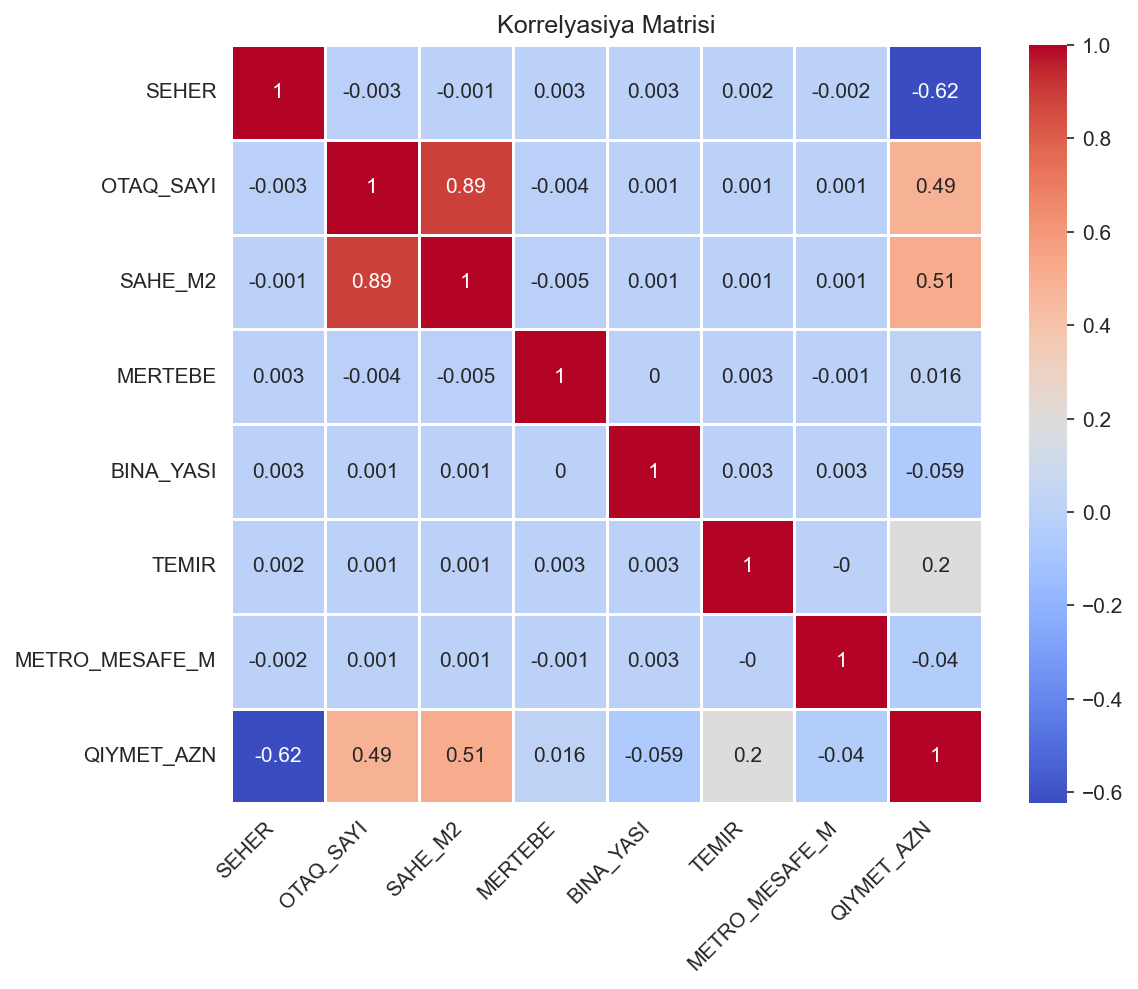

In [424]:
dpi=150
plt.figure(dpi=dpi , figsize=(8, 7))
sns.heatmap(round(df.corr() , 3) , annot=True , cmap='coolwarm' , linewidths=0.5)
plt.title('Korrelyasiya Matrisi')
plt.tight_layout()
plt.xticks(rotation=45 , ha='right')
plt.show()

# pearsonun korelasyonudur bu

In [425]:
df.corr()['QIYMET_AZN'].sort_values(ascending=False)

QIYMET_AZN        1.000000
SAHE_M2           0.512183
OTAQ_SAYI         0.488090
TEMIR             0.197493
MERTEBE           0.016181
METRO_MESAFE_M   -0.039527
BINA_YASI        -0.059142
SEHER            -0.624088
Name: QIYMET_AZN, dtype: float64

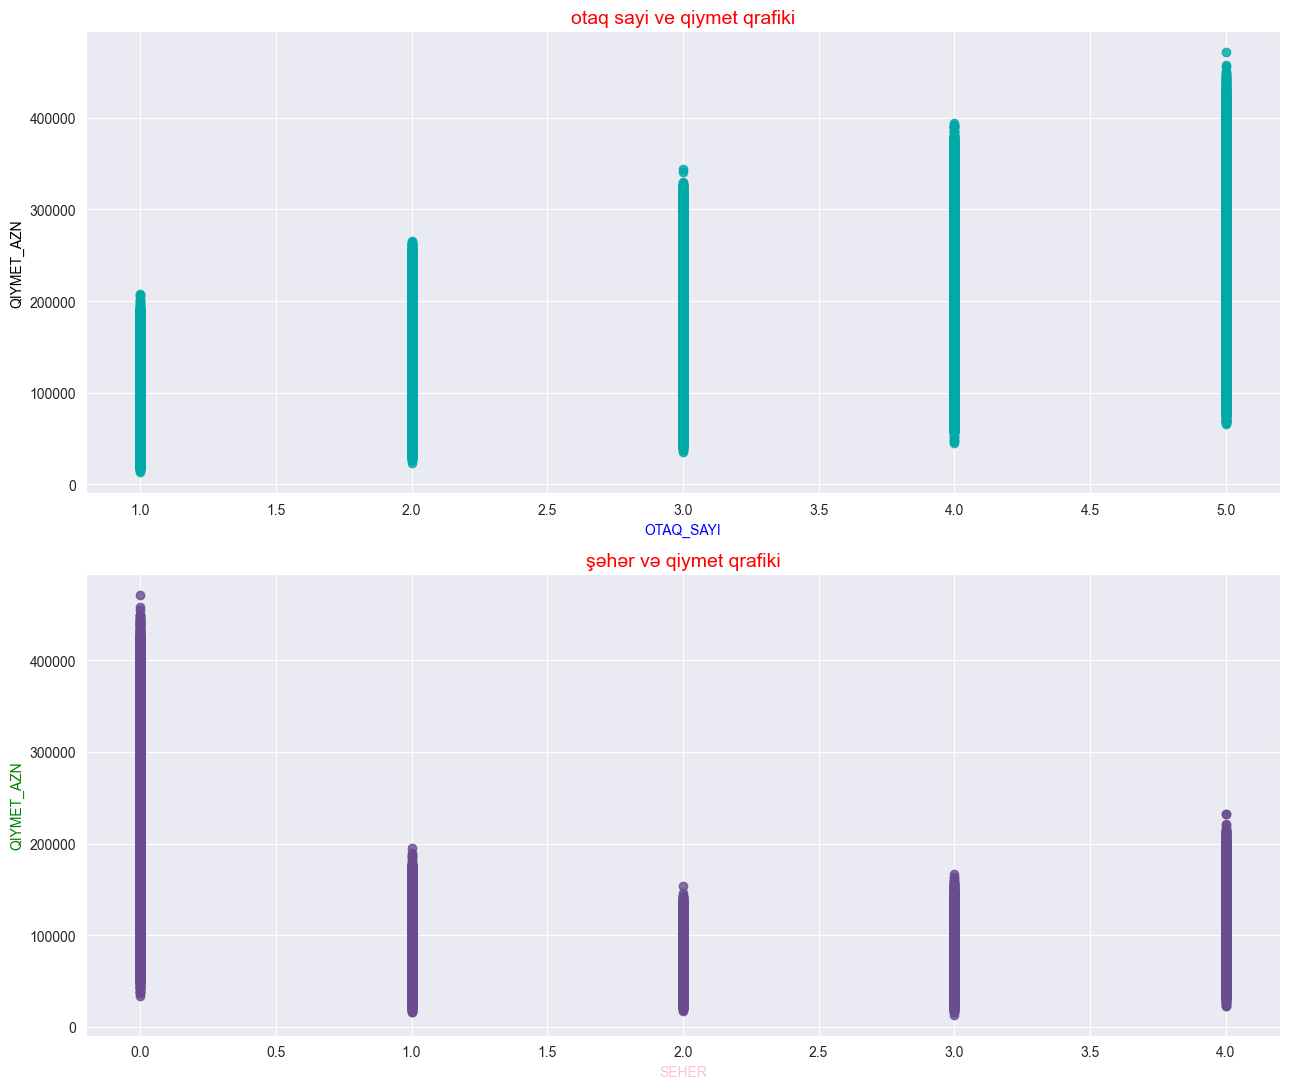

In [426]:
fig,axes = plt.subplots(2,1 , figsize=(13,11))
colors=['#FF6F61' ,'#6A4C90' , '#00A8A8', '#F4A261' ,'#3B9DF5' , '#9B59B6']



axes[0].scatter(df['OTAQ_SAYI'] , df['QIYMET_AZN'] , color=colors[2] , alpha=0.8)
axes[0].set_title('otaq sayi ve qiymet qrafiki' , fontsize=14 , color='red')
axes[0].set_xlabel('OTAQ_SAYI' , fontsize=10 , color= 'blue')
axes[0].set_ylabel('QIYMET_AZN' , fontsize=10 , color= 'black')

axes[1].scatter(df['SEHER'] , df['QIYMET_AZN'] , color=colors[1] , alpha=0.8)
axes[1].set_title('şəhər və qiymet qrafiki' , fontsize=14 , color='red')
axes[1].set_xlabel('SEHER' , fontsize=10 , color= 'pink')
axes[1].set_ylabel('QIYMET_AZN' , fontsize=10 , color= 'green')

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

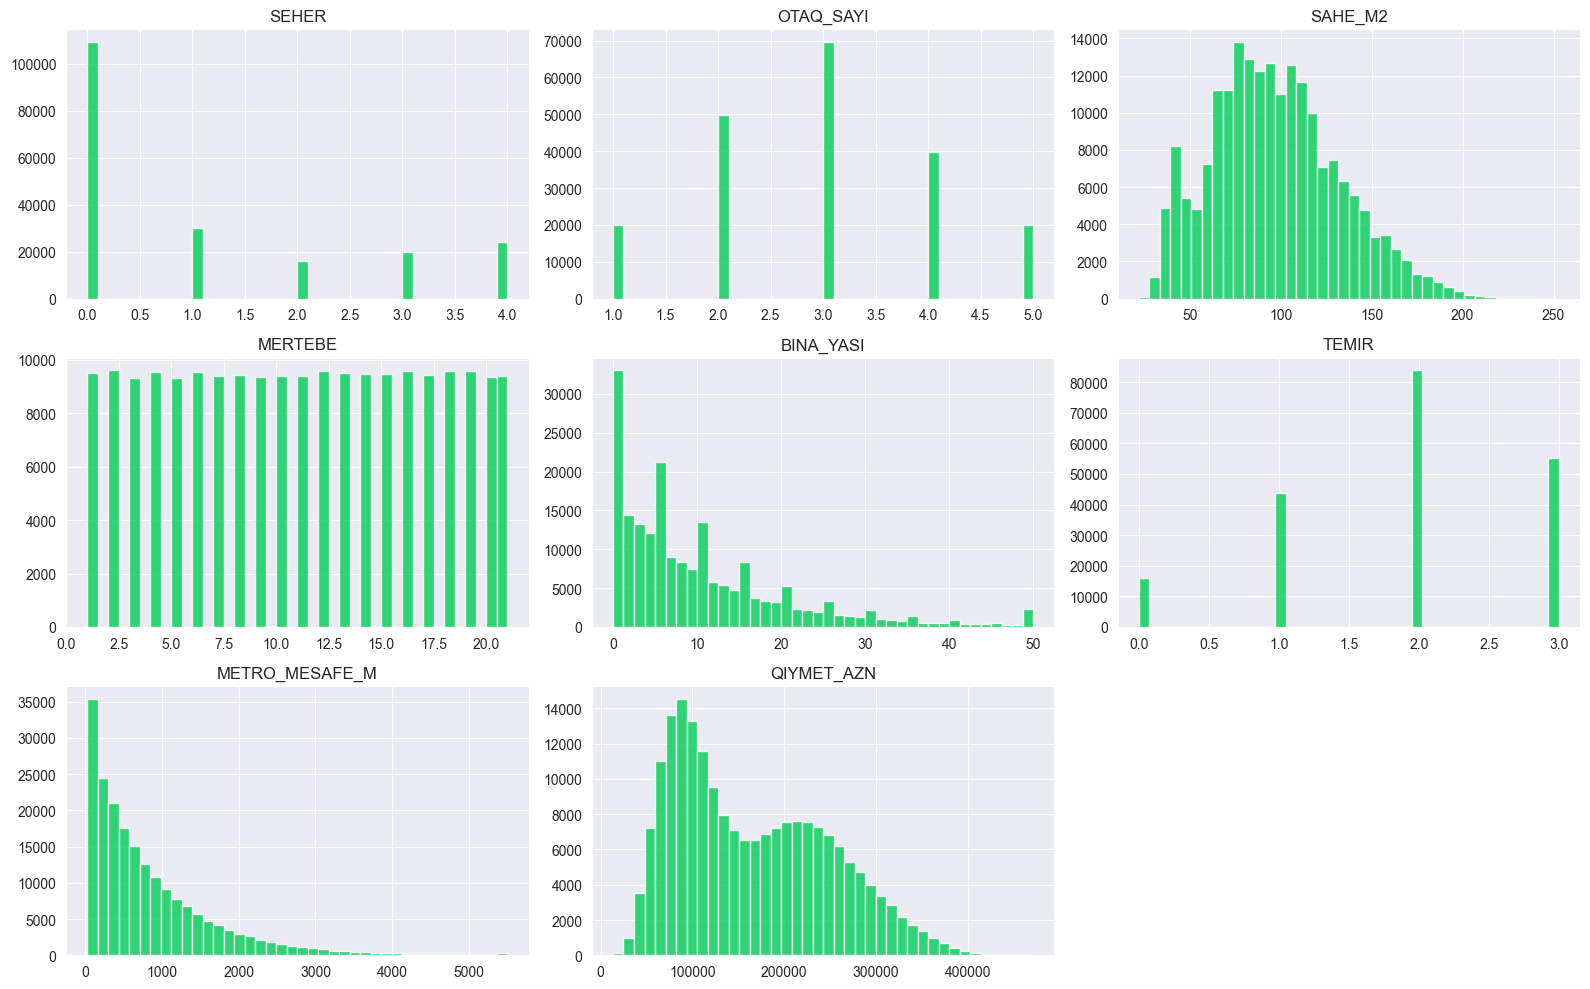

In [427]:
plt.figure(figsize=(15,10))
df.hist(bins=40 , color="#00CD55"  ,figsize=(16,10), grid=True , edgecolor='white', alpha=0.8)
plt.title('Sutunlarin Paylanmasi (Histogram)', fontsize=17, y=1.02)
plt.tight_layout()

In [428]:
df = df.rename(columns={
    'BINA_YASI': 'Bina',
    'METRO_MESAFE_M': 'Metrodan_uzaqliq', 
    'QIYMET_AZN': 'Qiymet',
    'SAHE_M2': 'Area_M2'
})
df

,SEHER,OTAQ_SAYI,Area_M2,MERTEBE,Bina,TEMIR,Metrodan_uzaqliq,Qiymet
0,1,3,88.0,11,0,3.0,2369.0,106155
1,4,4,174.0,9,0,1.0,172.0,157632
2,0,4,142.0,4,5,0.0,66.0,243584
3,0,4,91.0,5,1,1.0,101.0,233115
4,1,3,84.0,20,1,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...
198847,0,2,78.0,18,20,0.0,1913.0,123474
198848,1,3,119.0,14,17,3.0,756.0,115457
198849,0,4,82.0,9,10,3.0,479.0,260676
198850,3,1,52.0,12,18,1.0,159.0,43198


# Yalnız Bakı şəhərində 150 mindən bahalı evlərin qiyməti.

In [429]:
# df[(df['SEHER'] == 0) & (df['Qiymet'] > 150000)] alternativ yol
df.query('SEHER == 0 & Qiymet > 150000')

,SEHER,OTAQ_SAYI,Area_M2,MERTEBE,Bina,TEMIR,Metrodan_uzaqliq,Qiymet
2,0,4,142.0,4,5,0.0,66.0,243584
3,0,4,91.0,5,1,1.0,101.0,233115
5,0,2,53.0,12,7,2.0,65.0,163000
6,0,3,92.0,18,4,2.0,37.0,227971
12,0,3,120.0,2,6,1.0,30.0,245005
...,...,...,...,...,...,...,...,...
198839,0,3,88.0,10,8,3.0,272.0,233637
198841,0,3,83.0,9,13,3.0,2313.0,240034
198843,0,4,88.0,20,0,1.0,171.0,227688
198849,0,4,82.0,9,10,3.0,479.0,260676


In [430]:
df

,SEHER,OTAQ_SAYI,Area_M2,MERTEBE,Bina,TEMIR,Metrodan_uzaqliq,Qiymet
0,1,3,88.0,11,0,3.0,2369.0,106155
1,4,4,174.0,9,0,1.0,172.0,157632
2,0,4,142.0,4,5,0.0,66.0,243584
3,0,4,91.0,5,1,1.0,101.0,233115
4,1,3,84.0,20,1,2.0,1599.0,98474
...,...,...,...,...,...,...,...,...
198847,0,2,78.0,18,20,0.0,1913.0,123474
198848,1,3,119.0,14,17,3.0,756.0,115457
198849,0,4,82.0,9,10,3.0,479.0,260676
198850,3,1,52.0,12,18,1.0,159.0,43198


In [431]:
df.shape

(198852, 8)

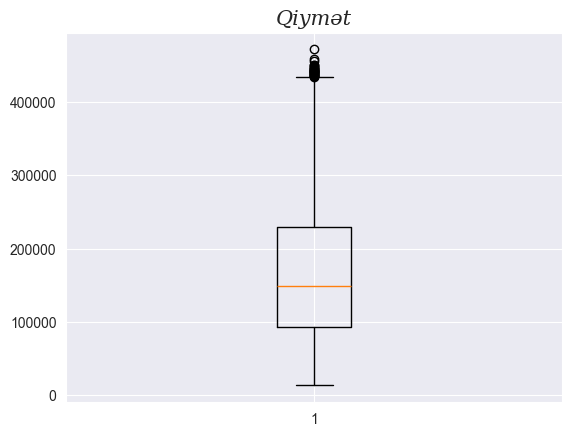

In [432]:
plt.boxplot(x='Qiymet', data=df)
plt.Figure(figsize=(8,7))
plt.grid(visible=True)
plt.title(
    label='Qiymət',
    fontdict={
        'fontfamily':'serif',
        'fontsize':15,
        'fontstyle':'italic',
        'fontweight':'light'
    }
)
q1 = df['Qiymet'].quantile(0.25)
q3 = df['Qiymet'].quantile(0.75)
iqr = q3 - q1
df = df[(df['Qiymet'] >= q1 - 1.5*iqr) & (df['Qiymet']<= q3+ 1.5*iqr)]

plt.show()



# skew = Datanın nə qədər ƏYRİ olduğunu ölçür (rəqəm verir)
# normaltest = Datanın NORMAL paylanıb-paylanmadığını yoxlayır (bəli/xeyr)

In [433]:
def skew_test(data:pd.DataFrame) -> pd.DataFrame:
    results = []
    for column in data.select_dtypes(include='number').columns:
        skewness = round(skew(data[column]) , 2)

        abs_value = abs(skewness)
        if abs_value < 0.5:
            severity = "Simmetrik"
        elif abs_value < 1:
            severity = "yungul eyri"
        elif abs_value < 2:
            severity = "orta eyri"
        else:
            severity = "guclu eyri"

        results.append({
            'column':column,
            'skewness':skewness,
            'severity':severity,
        })
    return pd.DataFrame(results)

In [434]:
test = skew_test(df) 
test

,column,skewness,severity
0,SEHER,0.98,yungul eyri
1,OTAQ_SAYI,0.10,Simmetrik
2,Area_M2,0.43,Simmetrik
3,MERTEBE,-0.01,Simmetrik
4,Bina,1.58,orta eyri
5,TEMIR,-0.46,Simmetrik
6,Metrodan_uzaqliq,1.88,orta eyri
7,Qiymet,0.50,yungul eyri


# əgərki mənfi və ya 0 dəyəri olarsa yeojonhson isdifadə etməliyik çünki boxcox qəbul etmir ancaq pozitiv dəyərlərlə dolu olmalıdır

# select.dtypes(include='number') isdifadə etməyə ehtiyac yoxdur çünki biz artıq rəqəmlərə çevirmişik dəyərləri

In [435]:
lambdas={}
def boxcox_yeojohnson(data:pd.DataFrame) -> pd.DataFrame:
    box_df = data.copy()
    for column in box_df.columns:
        if box_df[column].min() >0 :
            box_df[column] , lam = boxcox(box_df[column])
        else:
            box_df[column] , lam = yeojohnson(box_df[column])
        lambdas[column] = lam
    return box_df 

In [436]:
box_df = boxcox_yeojohnson(df)
box_df 

,SEHER,OTAQ_SAYI,Area_M2,MERTEBE,Bina,TEMIR,Metrodan_uzaqliq,Qiymet
0,0.506159,1.748304,16.081388,6.496064,0.000000,4.415067,19.750986,89.898739
1,0.819379,2.516822,23.209484,5.426518,0.000000,1.189413,9.322631,100.959287
2,0.000000,2.516822,20.832311,2.394714,2.048208,0.000000,6.744437,114.654018
3,0.000000,2.516822,16.379439,3.059349,0.729467,1.189413,7.825408,113.193865
4,0.506159,1.748304,15.675743,10.786986,0.729467,2.682593,17.796547,87.933854
...,...,...,...,...,...,...,...,...
198847,0.000000,0.922577,15.048190,9.889197,3.834431,0.000000,18.667849,93.981285
198848,0.506159,1.748304,18.947939,8.006265,3.596597,4.415067,14.493738,92.146239
198849,0.000000,2.516822,15.469197,5.426518,2.871690,4.415067,12.723909,116.944057
198850,0.766317,0.000000,11.987735,7.010642,3.679406,1.189413,9.090851,68.909728


In [437]:
def normaltests(data:pd.DataFrame)-> pd.DataFrame:
    results = []
    for column in data.columns:
        stat , p = normaltest(data[column])
        normal_test = 'Normal' if p > 0.05 else 'normal deyil'
        results.append({
            'Column': column,
            'Stat': round(stat, 2),
            'P_value': round(p, 5),
            'Status': normal_test
        })
    return pd.DataFrame(results)

In [438]:
normaltests(df)

,Column,Stat,P_value,Status
0,SEHER,28448.79,0.0,normal deyil
1,OTAQ_SAYI,8539.82,0.0,normal deyil
2,Area_M2,5754.37,0.0,normal deyil
3,MERTEBE,188163.23,0.0,normal deyil
4,Bina,55710.21,0.0,normal deyil
5,TEMIR,11713.92,0.0,normal deyil
6,Metrodan_uzaqliq,74711.26,0.0,normal deyil
7,Qiymet,19000.13,0.0,normal deyil


# burda method spearman verməkdə məqsəd datamız normal deyil

In [439]:
box_df.corr(method='spearman')['Qiymet'].sort_values(ascending=False)

Qiymet              1.000000
Area_M2             0.489118
OTAQ_SAYI           0.470301
TEMIR               0.191444
MERTEBE             0.015978
Metrodan_uzaqliq   -0.033892
Bina               -0.061007
SEHER              -0.750082
Name: Qiymet, dtype: float64

# artıq görünürki biz yeojhonsondan isdifadə edərək dataseti simmetrik hala gətirdik 

In [440]:
for column in box_df.select_dtypes(include='number').columns:
    skewness = round(skew(box_df[column]) , 2)

    abs_value = abs(skewness)
    if abs_value < 0.5:
        print(f"{column}: skew={skewness} = Simmetrik")
    elif abs_value < 1:
        print(f"{column}: skew={skewness} = yungul eyri")
    elif abs_value < 2:
        print(f"{column}: skew={skewness} = orta eyri")
    else:
        print(f"{column}: skew={skewness} = guclu eyri")

SEHER: skew=0.37 = Simmetrik
OTAQ_SAYI: skew=-0.08 = Simmetrik
Area_M2: skew=-0.03 = Simmetrik
MERTEBE: skew=-0.24 = Simmetrik
Bina: skew=-0.04 = Simmetrik
TEMIR: skew=-0.19 = Simmetrik
Metrodan_uzaqliq: skew=-0.05 = Simmetrik
Qiymet: skew=-0.05 = Simmetrik


# Regression-da b₀ (intercept) lazımdır . const sütunu = b₀ üçündür . VIF sütunların bir-birinə nə qədər oxşadığını yoxlayır.

In [441]:
X = df[['SEHER', 'Area_M2', 'OTAQ_SAYI']]
X_const = sm.add_constant(X)

for i, column in enumerate(X.columns):
    vif = variance_inflation_factor(X_const.values, i + 1)
    status = "olar" if vif < 5 else "Sil"
    print(f"{column}: VIF={round(vif, 2)} {status}")

SEHER: VIF=1.0 olar
Area_M2: VIF=4.77 olar
OTAQ_SAYI: VIF=4.77 olar


# Artıq model qura bilərik

In [442]:
X = box_df[['SEHER', 'Area_M2', 'OTAQ_SAYI']]
y = box_df['Qiymet']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# təsadüfi paylandı 0.2 sini test üçün verdim qalanını train yəni öyrənməyə

In [443]:
X_test

,SEHER,Area_M2,OTAQ_SAYI
174553,0.000000,19.203751,1.748304
174586,0.506159,13.241647,0.922577
114737,0.000000,13.829547,0.922577
153408,0.506159,9.528641,0.000000
75239,0.000000,16.379439,1.748304
...,...,...,...
97413,0.000000,18.159957,1.748304
61199,0.000000,13.361123,0.922577
48496,0.766317,13.121176,0.922577
109140,0.819379,17.707827,1.748304


# alpha cezalandırır. alpha=0     → heç cəza yoxdur (=LinearRegression)  alpha=0.01  → az cəza  ,  alpha=0.1   → orta cəza ,  alpha=1.0   → güclü cəza ,  alpha=10    → çox  ,  güclü cəza alpha=100   → həddən artıq cəza 
# Ridge(alpha=0.01) → az kiçildir
# Ridge(alpha=1.0)  → orta kiçildir (default) 
# Ridge(alpha=100)  → çox kiçildir


# Lasso(alpha=0.01) → az silir
#  Lasso(alpha=0.1)  → orta silir 
#  Lasso(alpha=1.0)  → çox silir
#  Lasso(alpha=10)   → demək olar hamısını silir

# l1_ratio=0.3 → 30% Lasso + 70% Ridge
# l1_ratio=0.5 → yarı-yarı 

#  Sabit (intercept) əlavə edir.  add_constant


In [444]:
pipelines = {
    'Linear': Pipeline([('scaler' , StandardScaler()) , ('model' , LinearRegression(n_jobs=-1 , copy_X=True ,fit_intercept=True))]),
    'Ridge' : Pipeline([('scaler' , StandardScaler()) , ('model', Ridge(alpha=1.0))]),
    'Lasso' : Pipeline([('scaler' , StandardScaler()) , ('model' , Lasso(alpha=0.1))]),
    'ElasticNet': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(alpha=0.1, l1_ratio=0.5))])
}

for name , pipe in pipelines.items():
    pipe.fit(X_train ,y_train)
    y_pred = pipe.predict(X_test)
    r2 = round(r2_score(y_test , y_pred), 4)
    mae = round(mean_absolute_error(y_test , y_pred) , 2)
    rmse = round(np.sqrt(mean_squared_error(y_test , y_pred)) ,4)
    print(f"{name}: R2={r2}, MAE={mae}, RMSE={rmse}")
    

X_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_const).fit()
print(model.summary())


Linear: R2=0.8555, MAE=4.81, RMSE=5.9713


Ridge: R2=0.8555, MAE=4.81, RMSE=5.9713
Lasso: R2=0.8554, MAE=4.83, RMSE=5.9725
ElasticNet: R2=0.8537, MAE=4.94, RMSE=6.0081
                            OLS Regression Results                            
Dep. Variable:                 Qiymet   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                 3.147e+05
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:25:36   Log-Likelihood:            -5.0968e+05
No. Observations:              159057   AIC:                         1.019e+06
Df Residuals:                  159053   BIC:                         1.019e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------

# pipe    = Pipeline (scaler + model birlikdə)
# X_train = suallar (SEHER, Area, Otaq)
# y_train = cavablar (Qiymet)
# cv=5    = 5 dəfə böl və yoxla
# scoring='r2' = hər dəfə R² hesabla

In [445]:
from sklearn.model_selection import cross_val_score

for name , pipe in pipelines.items():
    scores = cross_val_score(pipe , X_train , y_train , cv=5 , scoring='r2')
    print(f"{name}: CV R2={round(scores.mean(), 4)}")

Linear: CV R2=0.8558
Ridge: CV R2=0.8558
Lasso: CV R2=0.8557
ElasticNet: CV R2=0.8537


# artıq görünürki biz cross valdition etdikdən sonra nəticə linear və ridge də yaxşı çıxdı biz linearı seçirik çünki sadədir mürəkkəb parametrlər isdifadə etmir 

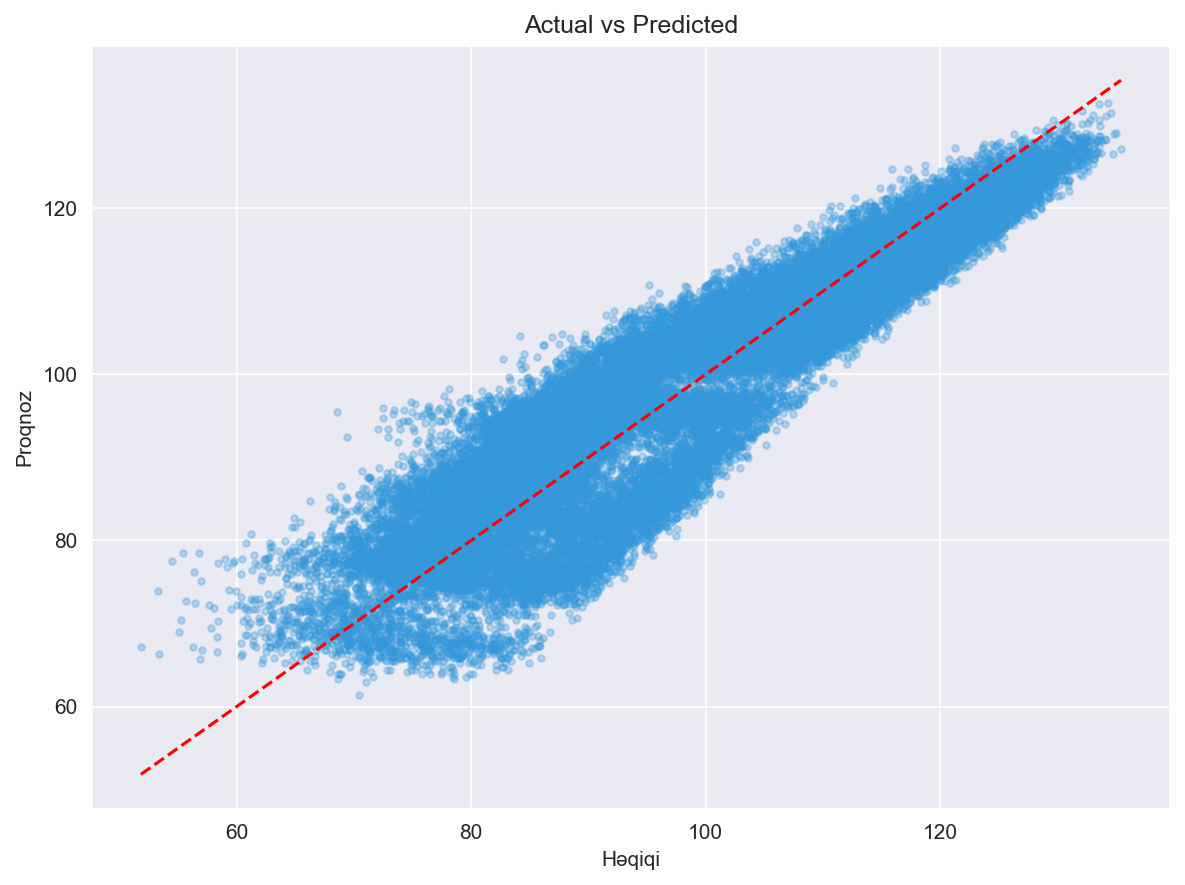

In [446]:
best = pipelines['Linear']
best.fit(X_train, y_train)
y_pred = best.predict(X_test)

sns.set_style('darkgrid')
plt.figure(figsize=(8, 6), dpi=150)
plt.scatter(y_test, y_pred, alpha=0.3, color='#3498DB', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Həqiqi')
plt.ylabel('Proqnoz')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()

# Modelin hər ev üçün nə qədər səhv etdiyini göstərir.

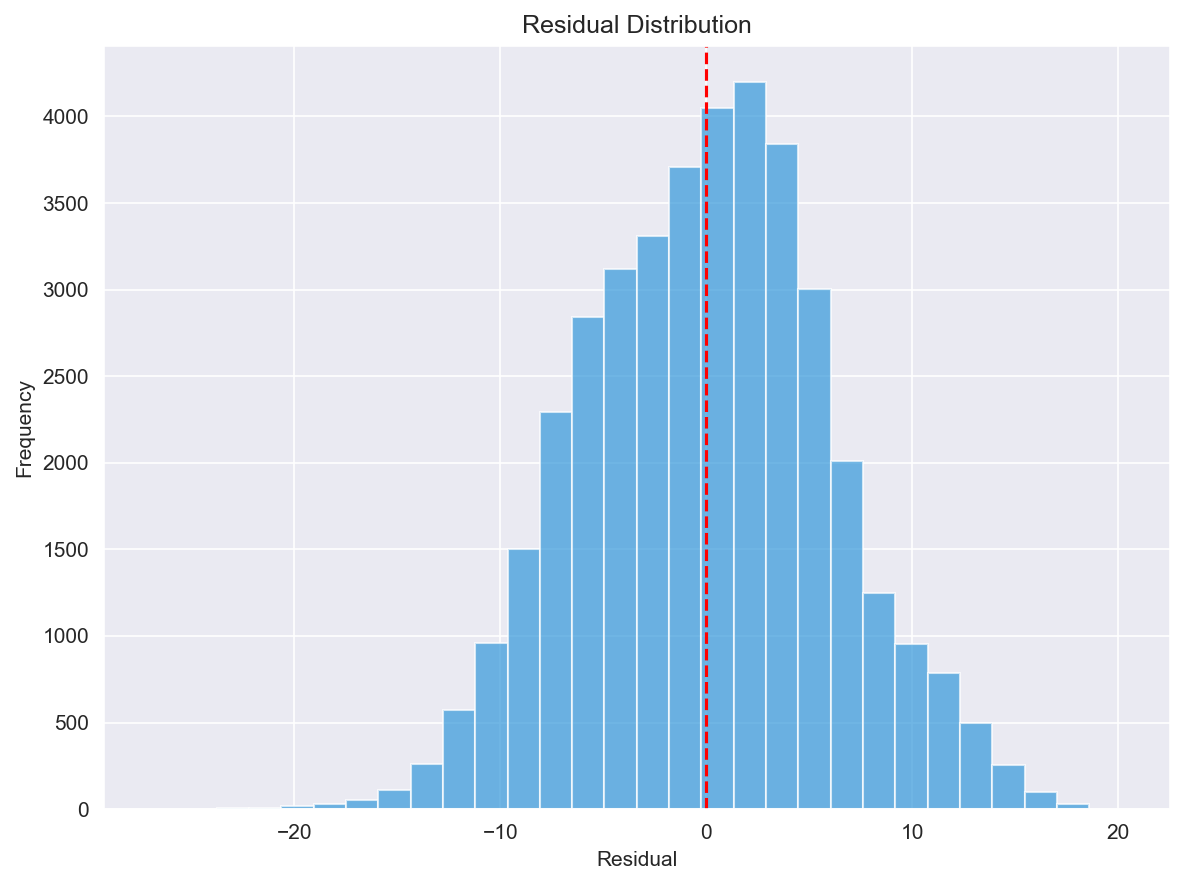

In [447]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6), dpi=150)
plt.hist(residuals, bins=30, color='#3498DB', edgecolor='white', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

# Əsas model daha yüksək dəqiqlik üçün transformasiya edilmiş datada öyrədilib (R²=0.856). Həqiqi AZN proqnozu üçün orijinal miqyasda yenidən öyrədirik.

In [448]:
predictor = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
predictor.fit(df[['SEHER', 'Area_M2', 'OTAQ_SAYI']], df['Qiymet'])

new_house = pd.DataFrame({'SEHER': [0], 'Area_M2': [100], 'OTAQ_SAYI': [3]})
price = predictor.predict(new_house)
print(f"Proqnoz qiymət: {price[0]:,.0f} AZN")

Proqnoz qiymət: 206,962 AZN
